In [ ]:
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn openpyxl

# **Building and Deploying a Machine Learning Model: A Hands-On Workshop**

**Instructor**: James Gray  
**Web**: http://www.jamesgray.ai  
**Email**: james@jamesgray.ai  
___

Welcome to this hands-on workshop! In this notebook, I will guide you through the **end-to-end machine learning lifecycle**, step by step. You’ll learn how to prepare data, train a machine learning model, and evaluate its performance.

---



## **What You’ll Need**
### *Requirements for This Workshop*

1. **No prior experience with machine learning is required**.
2. **Basic familiarity with Python** is helpful but not mandatory.
3. **Google Colab**: A web IDE for developing code in Python.
  - This is free - all you need is a Google account.
   - This notebook is designed to run on Google Colab, so no local installation is needed.
   - You can enable a GPU runtime for faster training (go to `Runtime > Change runtime type > GPU`).

4. **The Dataset**:
   - We will use an **[Excel spreadsheet](https://docs.google.com/spreadsheets/d/1ftAJgKuTpQ3HYhSvDOLSOBynMLW6Or3H/edit?usp=sharing&ouid=103034995099698352255&rtpof=true&sd=true)** containing employee data with features such as Age, Salary, and Job Satisfaction.
   - The dataset is small enough for easy exploration but realistic enough to demonstrate key ML concepts.

   ---

## **Machine Learning Lifecycle**
Machine learning is a process of steps to build, test, deploy, and monitor an application. There are many frameworks out there, and I picked one from Amazon Web Services that we will use to guide this workshop.

Source: [AWS Well-Architected Framework](https://docs.aws.amazon.com/wellarchitected/latest/machine-learning-lens/well-architected-machine-learning-lifecycle.html)


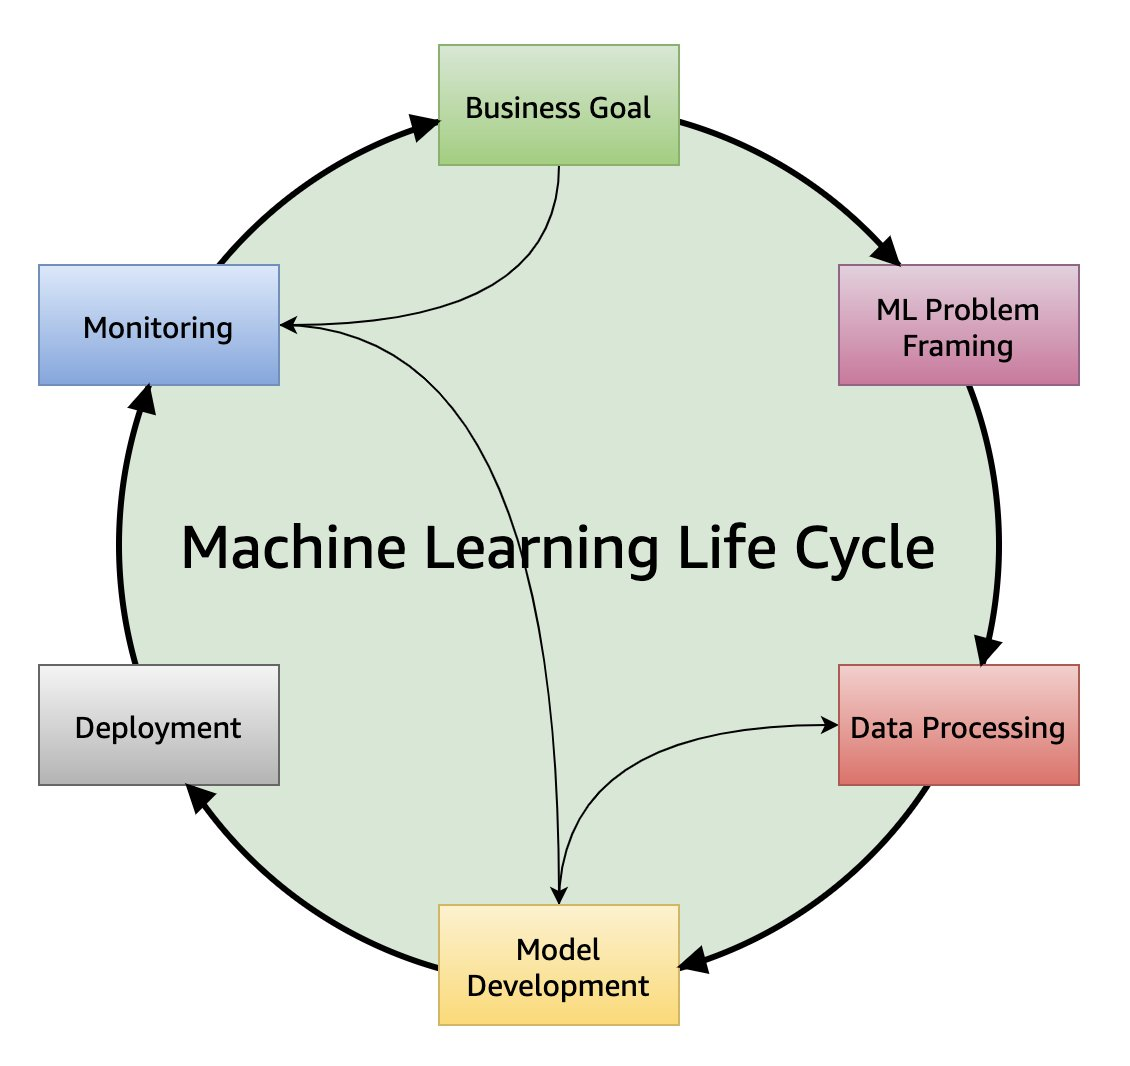

### **Lifecycle Steps**

1.  **Business Goal**: Clarity of the problem, and the
business value to be gained by solving that problem. You must be able to measure business value against specific business objectives and success criteria.
2. **ML Problem Framing**: The business problem is framed as a machine learning problem: what is observed and what should be predicted. Determining what to predict and how performance and error metrics must be optimized.
3. **Data Processing**: Training an accurate ML model requires data processing to convert data into a usable format. Collecting data, preparing data, and feature engineering (the process of creating, transforming, extracting, and selecting variables from data).
4. **Model Development**: Model development consists of model building, training, tuning, and evaluation. Model building includes creating a CI/CD pipeline that automates the build, train and release to staging and production environments.
5. **Deployment**: After a model is trained, tuned, evaluated and validated, you can deploy the model into production. You can then make predictions and inferences against the model.
6. **Monitoring**: Ensures your model is maintaining a desired level of performance through early detection and mitigation.

---



## **Getting Started**
Let’s dive into the notebook! Run the cells sequentially to follow the workshop step by step.

---

## **Import Python Libraries**
We need to "import" Python libraries into our notebook so we can use them.

In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn openpyxl


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# Import TensorFlow machine learning library
import tensorflow as tf
# Import Pandas for storing and manipulating the Excel dataset
import pandas as pd
# Import NumPy for numerical operations
import numpy as np

---

# **Step 1: Business Goal**
### *Defining the Problem and Business Value*

Every machine learning project starts with a clear understanding of the **problem** and its **business value**. For this workshop, our business goal is:

- **Business Problem**: High attrition increases costs for hiring and training new employees.
- **Business Goal**: Predict which employees are likely to leave and implement retention strategies.
- **Success Criterion**: Achieve 80% accuracy in predicting attrition.


### **Key Questions:**
1. What features (data) might influence employee attrition?
2. How can we measure the success of our predictions?
---

# **Step 2: ML Problem Framing**
### *Transforming the Business Goal into a Machine Learning Problem*

Here, we convert the business problem into a machine learning problem by identifying:
- **Observations (Features)**: Information about employees (e.g., Age, Salary, Workload).
- **Prediction (Target)**: Whether an employee will leave the company (1 = Yes, 0 = No).
- **Performance Metrics**: We’ll evaluate the model using **accuracy** and **confusion matrices**.


In this ML application, we are going to use 6 features - the "predictors" - that likely influence employee retention:
1. **Age**: Numerical, representing the employee’s age.
2. **Salary**: Numerical, annual salary in USD.
3. **Job Satisfaction**: Categorical (1-4), with 1 = very dissatisfied, 4 = very satisfied.
4. **Workload**: Numerical, percentage workload (0-100%).
5. **YearsAtCompany**: Numerical, years the employee has been with the company.
6. **Promotions**: Binary, 1 if the employee has been promoted, 0 otherwise.

I also expanded the predictors in the dataset used below.

---

# **Step 3: Data Processing**
### *Preparing the Data for Machine Learning*

Data processing is a crucial step in the machine learning lifecycle. It involves preparing raw data so that it can be effectively used by machine learning models.

## **Step 3A: Exploratory Data Analyis (EDA)**
This is where we explore the dataset and evaluate what types of processing we need to do. This may include handling missing values, normalizing or scaling numerical features, or encoding categorical variables.

The dataset (Excel file) includes 100 rows of observations with this inputs (also called features):
1. Age: Numerical, representing the employee’s age.
2. Salary: Numerical, annual salary in USD.
3. Job Satisfaction: Categorical (1-4), with 1 = very dissatisfied, 4 = very satisfied.
4. Workload: Numerical, percentage workload (0-100%).
5. YearsAtCompany: Numerical, years the employee has been with the company.
6. Promotions: Binary, 1 if the employee has been promoted, 0 otherwise.

The target variable (what we are predicting - yes/no):
7. LeftCompany: Binary, 1 if the employee left the company, 0 if they stayed

### Pandas DataFrame
A **DataFrame** is like a digital spreadsheet in Python, used to store and manipulate tabular data. It’s provided by the powerful Pandas library and is one of the most commonly used data structures for working with structured data like Excel files.
- A DataFrame organizes data into rows (observations) and columns (features), just like an Excel spreadsheet.
- Column headers are like the titles of each column in Excel.
- Row indices are numbers that help identify each row.
- You can filter, sort, and manipulate data quickly using built-in functions.


In [6]:
# load and display the dataset

file_path = 'data/company_attrition_dataset_3.xlsx'

df = pd.read_excel(file_path)
print("Raw Dataset:")
# display the first 10 rows of the DataFrame
df.head(10)

Raw Dataset:


,EmployeeID,Age,Department,JobRole,JobRoleGroup,Salary,YearsAtCompany,YearsSinceLastPromotion,JobSatisfaction,WorkLifeBalance,Overtime,RemoteWork,ManagerRating,StagnationRatio,Overtime_WorkLife,LowSatisfaction_Overtime,Salary_Department,LeftCompany
0,1,59,Sales,Sales Executive,Sales,61284,19,14,3,3,0,0,2,0.736842,0,0,3225.473684,1
1,2,39,Sales,Sales Executive,Sales,66023,10,10,3,4,0,0,5,1.000000,0,0,6602.300000,1
2,3,22,IT,System Administrator,Technical,72433,11,5,4,1,0,1,4,0.454545,0,0,6584.818182,1
3,4,41,R&D,Product Developer,Technical,118707,0,0,2,1,0,1,5,0.000000,0,0,118707.000000,0
4,5,45,IT,Software Engineer,Technical,88431,16,9,4,3,0,0,4,0.562500,0,0,5526.937500,0
5,6,36,HR,HR Manager,HR,59118,14,13,2,3,0,1,3,0.928571,0,0,4222.714286,0
6,7,23,Finance,Accountant,Finance,101606,4,2,1,3,1,0,1,0.500000,2,1,25401.500000,0
7,8,59,Sales,Sales Executive,Sales,58792,17,3,4,3,0,0,2,0.176471,0,0,3458.352941,0
8,9,29,Finance,Financial Analyst,Finance,83483,1,1,3,4,1,0,4,1.000000,1,0,83483.000000,0
9,10,28,IT,System Administrator,Technical,84541,14,2,1,3,0,0,4,0.142857,0,0,6038.642857,0


## **Step 3B: Feature Engineering**

**Feature engineering** is the process of selecting, transforming, and creating features to improve model performance.
- Models rely on features to learn patterns. Better features = better predictions.
- Helps reduce noise, capture relationships, and improve interpretability.


---

## **Step 3C: Preprocessing**

- Normalizing numerical features (e.g., Salary, Workload).
- Encoding categorical features (e.g., Job Satisfaction).

### Normalize Numerical Features

- Different numerical features often have varying scales (e.g., Salary ranges in thousands, while Workload is a percentage).
- Machine learning models perform better when all features have comparable scales. Without normalization:
  - Features with larger values can dominate, leading to biased results.
  - Optimization algorithms may converge slower.

In [7]:
# Step 1: Dynamically Select Numerical Columns to Normalize
# Exclude non-feature columns (like EmployeeID, LeftCompany) and binary/categorical-like numerical columns (like JobSatisfaction)
# Identify numerical columns
numerical_cols_all = df.select_dtypes(include=np.number).columns.tolist()

# Define columns to exclude from normalization (only include columns that exist in the dataframe)
possible_cols_to_exclude = ['EmployeeID', 'LeftCompany', 'JobSatisfaction', 'Promotions', 'Overtime', 'RemoteWork', 'Overtime_WorkLife', 'LowSatisfaction_Overtime']
# Filter to only include columns that exist AND are numerical
cols_to_exclude = [col for col in possible_cols_to_exclude if col in df.columns and col in numerical_cols_all]

# Determine which numerical columns to normalize
numerical_columns_to_normalize = [col for col in numerical_cols_all if col not in cols_to_exclude]

print(f"Columns to exclude from normalization: {cols_to_exclude}")
print(f"Numerical columns selected for normalization: {numerical_columns_to_normalize}")

# Create a new DataFrame with the numerical columns we need to scale
numerical_data = df[numerical_columns_to_normalize]

# Step 2: Create a Normalization Layer to scale the data
normalizer = tf.keras.layers.Normalization(axis=-1)

# Step 3: Adapt the Normalizer to the Data
# This calculates the mean and variance of the numerical columns and stores the
# results in the layer
# Convert numerical_data to a NumPy array for TensorFlow compatibility
normalizer.adapt(numerical_data.to_numpy())

# Step 4: Normalize the Data (stored as a tensor)
normalized_data = normalizer(numerical_data.to_numpy())

# Step 5: Convert the normalized data back into a DataFrame
normalized_df = pd.DataFrame(
    normalized_data.numpy(),
    columns=numerical_columns_to_normalize
)

# Step 6: Add back the excluded numerical columns and the target variable to the normalized DataFrame
# Add back the excluded numerical columns that were not normalized (only if there are any)
if len(cols_to_exclude) > 0:
    excluded_numerical_df = df[cols_to_exclude]
    # Concatenate normalized numerical features and excluded numerical features
    final_normalized_df = pd.concat([normalized_df, excluded_numerical_df], axis=1)
else:
    # No columns to exclude, just use normalized data
    final_normalized_df = normalized_df

# Display the final normalized dataset
print("\nNormalized Dataset:")
print(final_normalized_df.head())

# Step 7: Save the Normalized Dataset as a New Excel File
#normalized_file_path = '/content/drive/My Drive/Colab Notebooks/Employee_Attrition_Data_Normalized.xlsx'
#final_normalized_df.to_excel(normalized_file_path, index=False)
#print(f"\nNormalized data saved to: {normalized_file_path}")

Columns to exclude from normalization: ['EmployeeID', 'LeftCompany', 'JobSatisfaction', 'Overtime', 'RemoteWork', 'Overtime_WorkLife', 'LowSatisfaction_Overtime']
Numerical columns selected for normalization: ['Age', 'Salary', 'YearsAtCompany', 'YearsSinceLastPromotion', 'WorkLifeBalance', 'ManagerRating', 'StagnationRatio', 'Salary_Department']

Normalized Dataset:
        Age    Salary  YearsAtCompany  YearsSinceLastPromotion  \
0  1.694164 -1.107817        1.667988                 2.093543   
1 -0.080016 -0.887894        0.113962                 1.195797   
2 -1.588068 -0.590425        0.286631                 0.073615   
3  0.097402  1.557011       -1.612734                -1.048567   
4  0.452238  0.151993        1.149979                 0.971361   

   WorkLifeBalance  ManagerRating  StagnationRatio  Salary_Department  \
0         0.372455      -0.742796         0.805760          -0.664044   
1         1.259253       1.335923         1.570807          -0.527331   
2        -1.401

In [8]:
print(df.columns.tolist())

['EmployeeID', 'Age', 'Department', 'JobRole', 'JobRoleGroup', 'Salary', 'YearsAtCompany', 'YearsSinceLastPromotion', 'JobSatisfaction', 'WorkLifeBalance', 'Overtime', 'RemoteWork', 'ManagerRating', 'StagnationRatio', 'Overtime_WorkLife', 'LowSatisfaction_Overtime', 'Salary_Department', 'LeftCompany']


In [9]:
print(df.columns)

Index(['EmployeeID', 'Age', 'Department', 'JobRole', 'JobRoleGroup', 'Salary',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'JobSatisfaction',
       'WorkLifeBalance', 'Overtime', 'RemoteWork', 'ManagerRating',
       'StagnationRatio', 'Overtime_WorkLife', 'LowSatisfaction_Overtime',
       'Salary_Department', 'LeftCompany'],
      dtype='object')


### **Encoding Categorical Variables**
#### What is Encoding?
Encoding categorical variables is the process of converting non-numerical data (like categories or text) into numerical values that can be understood by machine learning models. Most models cannot directly handle categorical data, so encoding ensures that this information is properly represented.

#### Why is Encoding Important?
1. **Model Compatibility**: Machine learning models require numerical inputs. Encoding makes categorical data usable by models like regression, neural networks, and decision trees.
2. **Preserves Information**: Proper encoding ensures that the relationships or distinctions between categories are preserved (e.g., ordinal vs. nominal data).
3. **Prevents Misinterpretation**: Without encoding, models might incorrectly interpret categories as continuous or ordinal when they are not, leading to poor predictions.

### Types of Encoding:
1. **Label Encoding**: Assigns each category a unique number (e.g., 1, 2, 3). Best for ordinal data, where the order matters.
2. **One-Hot Encoding**: Converts each category into a binary column (e.g., 0 or 1). Best for nominal data, where the order does not matter.

### Why We Didn't Encode `JobSatisfaction`
In this notebook, the **`JobSatisfaction`** column is already ordinal (`1 = Very Dissatisfied`, `4 = Very Satisfied`). Since the order of the values matters and the data is already represented numerically, no additional encoding was required.

---

In [10]:
# Step 1: Select Categorical Columns to One-Hot Encode
categorical_columns = ['Department', 'JobRoleGroup']

# Step 2: Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Display the first 10 rows of the DataFrame with one-hot encoded columns
print("DataFrame with One-Hot Encoded Columns:")
display(df_encoded.head(10))

DataFrame with One-Hot Encoded Columns:


,EmployeeID,Age,JobRole,Salary,YearsAtCompany,YearsSinceLastPromotion,JobSatisfaction,WorkLifeBalance,Overtime,RemoteWork,...,LowSatisfaction_Overtime,Salary_Department,LeftCompany,Department_HR,Department_IT,Department_R&D,Department_Sales,JobRoleGroup_HR,JobRoleGroup_Sales,JobRoleGroup_Technical
0,1,59,Sales Executive,61284,19,14,3,3,0,0,...,0,3225.473684,1,False,False,False,True,False,True,False
1,2,39,Sales Executive,66023,10,10,3,4,0,0,...,0,6602.300000,1,False,False,False,True,False,True,False
2,3,22,System Administrator,72433,11,5,4,1,0,1,...,0,6584.818182,1,False,True,False,False,False,False,True
3,4,41,Product Developer,118707,0,0,2,1,0,1,...,0,118707.000000,0,False,False,True,False,False,False,True
4,5,45,Software Engineer,88431,16,9,4,3,0,0,...,0,5526.937500,0,False,True,False,False,False,False,True
5,6,36,HR Manager,59118,14,13,2,3,0,1,...,0,4222.714286,0,True,False,False,False,True,False,False
6,7,23,Accountant,101606,4,2,1,3,1,0,...,1,25401.500000,0,False,False,False,False,False,False,False
7,8,59,Sales Executive,58792,17,3,4,3,0,0,...,0,3458.352941,0,False,False,False,True,False,True,False
8,9,29,Financial Analyst,83483,1,1,3,4,1,0,...,0,83483.000000,0,False,False,False,False,False,False,False
9,10,28,System Administrator,84541,14,2,1,3,0,0,...,0,6038.642857,0,False,True,False,False,False,False,True


## **Step 3D: Splitting the Data**

### 1. Why Split the Data?
- **Training Set**: Used to train the model and learn patterns from the data.
- **Test Set**: Used to evaluate the model’s performance on unseen data and check its generalization ability.

### 2. Common Split Ratio
- A typical ratio is **80% training / 20% testing**, but this can vary depending on the dataset size and use case.

### 3. Tool for Splitting
- We’ll use **TensorFlow's `tf.data` API** to split the dataset. This approach is efficient, integrates seamlessly with TensorFlow models, and allows us to easily shuffle and batch the data.

These are a few operations we do while splitting the data.

### **Dataset Shuffling**
Shuffling ensures that the data is randomly ordered before training. This prevents the model from learning patterns based on the original order of the data rather than the actual relationships between features.

### **Batches**
Batch size is the number of data samples processed together during one training step. Instead of processing the entire dataset at once, the model works on smaller chunks (batches), which:
- Improves memory efficiency (especially for large datasets).
- Speeds up training by updating weights more frequently.
- Choosing a Batch Size:
  - Typical values: 16, 32, 64, or 128.
  - Smaller batch sizes are slower but can yield better results in some cases.
  - Larger batch sizes are faster but may require more memory.

  ---

In [11]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Step 1: Separate Features (X) and Target (y)

# Perform One-Hot Encoding
categorical_columns = ['Department', 'JobRoleGroup']
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)


# Inspect data types of columns in df_encoded
print("Data types of df_encoded columns:")
print(df_encoded.dtypes)

# Print unique values for object type columns to identify non-numerical data
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        print(f"\nUnique values in column '{col}':")
        print(df_encoded[col].unique())


X = df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']).to_numpy()  # Convert to NumPy, exclude EmployeeID and JobRole as they're not features
y = df_encoded['LeftCompany'].to_numpy()

# Convert X and y to a supported data type (e.g., float32)
X = X.astype(np.float32)
y = y.astype(np.float32)


# Step 2: Split Data Using TensorFlow
# Set the split ratio (80% training, 20% testing)
split_ratio = 0.8
train_size = int(split_ratio * len(X))

# Shuffle and split the data
dataset = tf.data.Dataset.from_tensor_slices((X, y))  # Create a TensorFlow Dataset
dataset = dataset.shuffle(buffer_size=len(X), seed=42, reshuffle_each_iteration=False)

train_dataset = dataset.take(train_size)  # Take the first 80% for training
test_dataset = dataset.skip(train_size)   # Skip the first 80%, take the rest for testing

# Step 3: Batch the Data
# Use batching for training and testing
batch_size = 32
train_dataset = train_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

# Print dataset sizes
print(f"Training dataset size: {len(list(train_dataset))} batches")
print(f"Testing dataset size: {len(list(test_dataset))} batches")

Data types of df_encoded columns:
EmployeeID                    int64
Age                           int64
JobRole                      object
Salary                        int64
YearsAtCompany                int64
YearsSinceLastPromotion       int64
JobSatisfaction               int64
WorkLifeBalance               int64
Overtime                      int64
RemoteWork                    int64
ManagerRating                 int64
StagnationRatio             float64
Overtime_WorkLife             int64
LowSatisfaction_Overtime      int64
Salary_Department           float64
LeftCompany                   int64
Department_HR                  bool
Department_IT                  bool
Department_R&D                 bool
Department_Sales               bool
JobRoleGroup_HR                bool
JobRoleGroup_Sales             bool
JobRoleGroup_Technical         bool
dtype: object

Unique values in column 'JobRole':
['Sales Executive' 'System Administrator' 'Product Developer'
 'Software Engineer' 'HR M

2025-10-02 12:22:05.038668: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-02 12:22:05.041378: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# **Step 4: Model Development**

### *Building and Training the Machine Learning Model*

This section outlines how we develop a binary classification model to predict employee attrition. We use TensorFlow's Keras API to build, train, and evaluate the model.

In this step, we:
1. Build a **binary classification model** using TensorFlow.
2. Train the model using the **training set**.
3. Evaluate its performance using the **test set**.


## **Workflow Instructions**

1. **Define the Model**:
   - Use the Keras Sequential API to build a neural network.
   - The model will include:
     - **Input Layer**: Matches the number of features (columns) in the dataset.
     - **Hidden Layers**: Layers of neurons that help the model learn patterns in the data.
     - **Output Layer**: A single neuron with a sigmoid activation function to predict probabilities (0 to 1) for binary classification.

2. **Compile the Model**:
   - Specify how the model will optimize its weights during training:
     - **Optimizer**: Adam (a widely used optimizer for neural networks).
     - **Loss Function**: Binary cross-entropy (suitable for binary classification problems).
     - **Evaluation Metrics**: Accuracy to monitor how well the model is performing.

3. **Train the Model**:
   - Fit the model to the training data and validate it on the test data.
   - Specify the number of training iterations (epochs) to allow the model to improve.

4. **Evaluate the Model**:
   - Use the test dataset to compute loss and accuracy, providing insights into how well the model generalizes to unseen data.

5. **Visualize Training Progress**:
   - Plot training and validation metrics (accuracy and loss) over epochs to monitor the model's learning progress.


## **What is the Keras Sequential API?**

The **Keras Sequential API** is a simple and intuitive way to build deep learning models in TensorFlow. It allows you to create a model layer by layer, where each layer has exactly one input tensor and one output tensor.

### **Key Features of the Sequential API**
1. **Simplicity**:
   - The Sequential API is straightforward to use, making it ideal for beginners and straightforward model architectures.
   - Layers are added in a linear stack, meaning the output of one layer becomes the input for the next.

2. **Flexibility**:
   - Supports a wide range of layer types (e.g., Dense, Dropout, Convolutional).
   - Works well for models where the flow of data is sequential.

3. **Integration**:
   - It integrates seamlessly with other TensorFlow components, like optimizers, loss functions, and metrics.

### **Why Are We Using the Sequential API?**
For this workshop, the Sequential API is a perfect choice because:
- The problem (binary classification) has a simple and linear data flow.
- It provides a clear and readable way to define the model architecture.
- The focus is on understanding the workflow rather than handling more complex architectures like branched or multi-input/output models.

### **How Does It Work?**
In the Sequential API:
1. Layers are defined one by one in the order they are executed.
2. Each layer performs a specific transformation on the data:
   - **Input Layer**: Specifies the shape of the data coming into the model.
   - **Hidden Layers**: Learn patterns in the data through weights and activations.
   - **Output Layer**: Produces the final prediction (e.g., probability of attrition).

   ---

## **Step 4A: Model Building and Training**

### **Neural Network Architecture**
In this section, we configure the end-to-end architecture of the neural network. Let's look at each part of the network.

#### **Input Layer**
- The input layer’s shape is determined by the number of features (columns) in the dataset. In our example, we have 6 features (the dataframe shape).
- Each feature (e.g., Age, Salary, etc.) corresponds to one neuron in the input layer.
- The input layer must match the number of features so the model can process all relevant information.

#### **Hidden Layers**
Hidden layers are the middle layers in a neural network that sit between the input layer (which takes in the data) and the output layer (which produces the prediction).
- **Role**: Hidden layers process and transform the input data to extract patterns and relationships that aren’t immediately obvious.
- **Why “Hidden”?**: They’re called “hidden” because their outputs are not directly visible; they exist to perform internal computations.
- The number of neurons in the hidden layers is not fixed—it’s often chosen experimentally.
- A common heuristic is to start with a number of neurons close to the number of input features or slightly higher and reduce it in subsequent layers.

In this example, we will use 2 hidden layers with 16 neurons in the first layer, and 8 neurons in the second layer.

- 16 neurons in the first hidden layer allow the model to learn more complex patterns.
- 8 neurons in the second hidden layer create a smaller, more focused representation of the data, reducing overfitting by compressing information.

*How many hidden layers are required?*

- For most problems, start with one or two hidden layers. Many practical problems (especially structured/tabular data) don’t require deep networks.
- If the model’s performance doesn’t meet expectations, experiment by adding more layers.
- Tasks with more features and non-linear relationships (e.g., employee attrition prediction) benefit from 2–3 hidden layers.
- Too many hidden layers can lead to overfitting, where the model learns noise instead of patterns.


**ReLu Activation**
- ReLU (Rectified Linear Unit) is computationally efficient and helps models learn non-linear patterns by outputting: $$ f(x) = \max(0, x) $$

- It works well for hidden layers by allowing the model to learn complex relationships.

#### **Output Layer**
- **1 neuron**: For binary classification, the output layer has one neuron that predicts the probability of a positive class (e.g., 1 = left the company).
- **Sigmoid activation**: Outputs a value between 0 and 1, representing the probability of the positive class.
- For binary classification, sigmoid activation makes it easy to interpret the output as a probability.

#### **Epochs**
An **epoch** is one complete pass through the entire training dataset during the training process of a machine learning model.

**Why Do We Need Multiple Epochs?**
- During training, the model updates its parameters (like weights) to minimize the error.
- A single pass (1 epoch) might not be enough for the model to learn all the patterns in the data.
- Multiple epochs allow the model to improve its understanding of the data by iteratively refining its predictions.


In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Step 1: Define the Model
# The Sequential API allows us to stack layers to build a neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),  # Input layer matching the number of features
    tf.keras.layers.Dense(18, activation='relu'),  # Hidden layer with 16 neurons and ReLU activation
    tf.keras.layers.Dense(8, activation='relu'),   # Hidden layer with 8 neurons and ReLU activation
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Step 2: Compile the Model
# Compile the model with an optimizer, loss function, and evaluation metrics.
model.compile(
    optimizer='adam',                          # Adam optimizer for efficient gradient descent
    loss='binary_crossentropy',                # Binary cross-entropy loss for binary classification
    metrics=['accuracy']                       # Track accuracy during training
)

# Display the model architecture
model.summary()

# Step 3: Train the Model
# Fit the model to the training dataset and validate it on the test dataset.
history = model.fit(
    train_dataset,                             # Training data
    epochs=20,                                 # Train for 20 iterations over the dataset
    validation_data=test_dataset,              # Validate on test data during training
    verbose=1                                  # Display progress during training
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 18)             │           378 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539 (2.11 KB)

 Trainable params: 539 (2.11 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6700 - loss: 3589.6016 - val_accuracy: 0.6100 - val_loss: 3523.3909
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - accuracy: 0.6700 - loss: 1965.2445 - val_accuracy: 0.6100 - val_loss: 1654.2015
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5700 - loss: 696.0123 - val_accuracy: 0.4600 - val_loss: 985.8789
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5825 - loss: 451.3882 - val_accuracy: 0.6100 - val_loss: 727.1931
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.5425 - loss: 318.8097 - val_accuracy: 0.6200 - val_loss: 480.3677
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.5625 - loss: 220.9125 - val_accuracy: 0.5500 - val_loss: 362.8173
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - accuracy: 0.6000 - loss: 158.2699 - val_accuracy: 0.5000 - val_loss: 252.8560
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.5700 - loss:

In [13]:
# Example new data (create a single sample with the same feature order as the dataset)
# Need to ensure the new employee data has the same number of features and order as df_encoded after dropping columns
# Let's create a sample new employee data based on the columns of df_encoded (excluding 'LeftCompany', 'EmployeeID', and 'JobRole')
new_employee_data_dict = {col: [0] for col in df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']).columns}

# Update the dictionary with values for the new employee
# Example values. Make sure to include values for all features used in the model.
new_employee_data_dict['Age'] = [50]
new_employee_data_dict['Salary'] = [100000] # Example salary
new_employee_data_dict['Workload'] = [75]
new_employee_data_dict['YearsAtCompany'] = [15]
new_employee_data_dict['JobSatisfaction'] = [4]
# Only set Promotions if it exists in the dataframe
if 'Promotions' in new_employee_data_dict:
    new_employee_data_dict['Promotions'] = [1]
new_employee_data_dict['WorkLifeBalance'] = [3]
new_employee_data_dict['Overtime'] = [0]
new_employee_data_dict['RemoteWork'] = [0]
new_employee_data_dict['ManagerRating'] = [4]

# For Department='Sales', set Department_Sales to 1 if it exists (assuming one-hot encoded columns)
if 'Department_Sales' in new_employee_data_dict:
    new_employee_data_dict['Department_Sales'] = [1]
# For JobRole='Sales Executive', this column is now dropped as JobRole is excluded


new_employee_df = pd.DataFrame(new_employee_data_dict)

# Identify numerical columns for normalization (excluding one-hot encoded and binary columns)
# Start with all columns in df_encoded except target, ID, and one-hot encoded
all_features = df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']) # Also drop JobRole here
one_hot_encoded_columns = [col for col in all_features.columns if '_' in col] # Simple heuristic for one-hot encoded columns

# Numerical columns are those not in one-hot encoded list and are of numerical dtype
numerical_columns = [col for col in all_features.columns if col not in one_hot_encoded_columns and all_features[col].dtype != 'object']

# Separate numerical and other features for prediction
new_employee_numerical = new_employee_df[numerical_columns]
new_employee_other_features = new_employee_df.drop(columns=numerical_columns)


# Step 1: Re-create and adapt the normalizer using the training data
# Need to get the training data X_train and y_train from the dataset splitting step
# We can reuse X from the dataset splitting cell (DOZoDGRIlNX6) which is the full feature set before splitting
X_train_full = X[:train_size] # Use the full X data up to the training size defined in DOZoDGRIlNX6

# Print shape of X_train_full and columns being used for debugging
print("Shape of X_train_full:", X_train_full.shape)
print("Columns of df_encoded after dropping:", df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']).columns.tolist())


# Create a DataFrame from the full training data to easily select columns
X_train_full_df = pd.DataFrame(X_train_full, columns=df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']).columns)

# Select only the numerical columns from the full training data to adapt the normalizer
X_train_numerical = X_train_full_df[numerical_columns].to_numpy()

# Create a new Normalization layer
normalizer = tf.keras.layers.Normalization(axis=-1)

# Adapt the normalizer to the numerical features of the training data
normalizer.adapt(X_train_numerical)


# Step 2: Normalize the numerical data of the new employee
normalized_new_employee_numerical = normalizer(new_employee_numerical.to_numpy())

# Step 3: Ensure the other features are in float32 for compatibility and the correct order
# Get the order of columns in X_train_full_df excluding numerical columns
other_feature_columns_order = X_train_full_df.drop(columns=numerical_columns).columns

# Select and reorder columns in new_employee_other_features to match the training data
new_employee_other_features_ordered = new_employee_other_features[other_feature_columns_order]

new_employee_other_features_float = tf.constant(new_employee_other_features_ordered.to_numpy(), dtype=tf.float32)


# Step 4: Combine normalized numerical and other features
final_new_employee = tf.concat([normalized_new_employee_numerical, new_employee_other_features_float], axis=1)


# Step 5: Predict the probability of attrition
prediction = model.predict(final_new_employee)
print(f"\nProbability of Attrition: {prediction[0][0]:.2%}")

# Step 6: Convert probability to binary prediction
threshold = 0.5
binary_prediction = int(prediction[0][0] > threshold)
print(f"Prediction: {'Will Leave' if binary_prediction == 1 else 'Will Stay'}")

Shape of X_train_full: (400, 20)
Columns of df_encoded after dropping: ['Age', 'Salary', 'YearsAtCompany', 'YearsSinceLastPromotion', 'JobSatisfaction', 'WorkLifeBalance', 'Overtime', 'RemoteWork', 'ManagerRating', 'StagnationRatio', 'Overtime_WorkLife', 'LowSatisfaction_Overtime', 'Salary_Department', 'Department_HR', 'Department_IT', 'Department_R&D', 'Department_Sales', 'JobRoleGroup_HR', 'JobRoleGroup_Sales', 'JobRoleGroup_Technical']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Probability of Attrition: 50.52%
Prediction: Will Leave


### **Neural Network Model Summary and Parameters**

The `model.summary()` command provides an overview of your neural network, showing the layers, their output shapes, and the number of trainable parameters. Here's what the table means:

---

#### **Column Descriptions**
1. **Layer (type)**:
   - Lists each layer in the model and its type.
   - Example: `dense` refers to a fully connected (Dense) layer.
2. **Output Shape**:
   - Shows the shape of the data after passing through the layer.
   - `None` indicates a dynamic batch size.
   - Numbers (e.g., 16, 8, 1) represent the number of neurons in that layer.
3. **Param #**:
   - The number of trainable parameters (weights and biases) for that layer.
   - Calculated as:
     - **Weights** = Inputs × Neurons
     - **Biases** = Neurons
     - **Total Parameters** = Weights + Biases

---

#### **Layer-by-Layer Breakdown**
1. **First Dense Layer**:
   - **16 neurons**.
   - **Input shape**: 6 features (e.g., `Age`, `Salary`, etc.).
   - **Parameters**:
     - Weights = \( 6 \times 16 = 96 \)
     - Biases = \( 16 \)
     - Total = \( 96 + 16 = 112 \)
2. **Second Dense Layer**:
   - **8 neurons**.
   - **Input shape**: 16 outputs from the first layer.
   - **Parameters**:
     - Weights = \( 16 \times 8 = 128 \)
     - Biases = \( 8 \)
     - Total = \( 128 + 8 = 136 \)
3. **Output Layer**:
   - **1 neuron** (binary classification).
   - **Input shape**: 8 outputs from the second layer.
   - **Parameters**:
     - Weights = \( 8 \times 1 = 8 \)
     - Biases = \( 1 \)
     - Total = \( 8 + 1 = 9 \)

---

#### **Summary**
- **Total Parameters**: \( 112 + 136 + 9 = 257 \)
- **Trainable Parameters**: All 257 parameters are adjusted during training.
- **Non-trainable Parameters**: None in this model.

---

This explanation helps you understand how data flows through the network and how parameters are calculated for each layer.

---

### **Interpreting Training Output Across Epochs**

When training a machine learning model, the output provides key metrics to track the model’s performance during each epoch. Here’s what to look for:

**Key Metrics:**
- Loss:
 - Measures how well the model’s predictions match the actual target values.
  - Lower loss = better performance.
- Accuracy:
 - Measures the percentage of correct predictions.
  - Higher accuracy = better performance.
- Validation Loss:
  - Measures the model’s performance on unseen (validation) data.
	- Indicates how well the model generalizes beyond the training data.
- Validation Accuracy:
	- Accuracy on the validation dataset.

**Expected Behavior:**
 - Loss should decrease over time as the model learns patterns in the training data.
 - Validation loss and accuracy:
  - If validation metrics improve alongside training metrics, the model is generalizing well.
  - If validation loss increases while training loss decreases, it may indicate overfitting.

**Signs to Watch For:**
- Overfitting:
	- Training loss continues to decrease, but validation loss increases.
	-	Example: The model memorizes training data but struggles with new data.
- Underfitting:
	-	Loss remains high, and accuracy does not improve over epochs.
	-	Example: The model is too simple or hasn’t trained long enough.

**Tips for Improvement:**
-	Use early stopping to halt training when validation loss stops improving.
-	Add regularization techniques (e.g., dropout) to reduce overfitting.
-	Experiment with hyperparameters like learning rate, batch size, or number of layers.

---

## **Step 4B: Model Evaluation**
Evaluate the model using metrics like accuracy, precision, recall, and F1 score.

The model's performance is evaluated on the test set using:
  - **Accuracy**: Proportion of correct predictions.
  - **Precision**: Proportion of predicted positives that are correct.
  - **Recall**: Proportion of actual positives identified correctly.
  - **F1 Score**: Balances precision and recall.

### **Loss and Accuracy**
- **Loss**: Guides the training process. A lower loss indicates better predictions.
- **Accuracy**: Helps assess the overall performance of the model on the dataset.
- Together, they provide a complete picture of model performance during training and evaluation.

---


### **Loss**

**What is Loss?**
- Loss measures how well the model’s predictions match the actual labels during training.
- The goal of training is to **minimize the loss**, which means the model’s predictions are improving.
- Loss is the primary feedback mechanism during model training. It directly drives the optimization process by guiding how the model updates its parameters.

**Binary Cross-Entropy Loss**
- \( y_i \): The true label (\( 0 \) or \( 1 \)).
- \( \hat{y}_i \): The predicted probability (output of the model, between \( 0 \) and \( 1 \)).
- The formula for binary cross-entropy loss is:

$$
\text{Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left( y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right)
$$

Where:
- \( N \): Total number of samples.
- \( y_i \): True label for sample \( i \) (\( 0 \) or \( 1 \)).
- \( \hat{y}_i \): Predicted probability for sample \( i \) (\( 0 \leq \hat{y}_i \leq 1 \)).

**Key Idea**
- This loss penalizes incorrect predictions more heavily as they deviate from the true label.
- The closer \( \hat{y}_i \) is to \( y_i \), the lower the loss for that sample.
- For example:
  - If \( y_i = 1 \) and \( \hat{y}_i = 0.9 \), the loss is small.
  - If \( y_i = 1 \) and \( \hat{y}_i = 0.1 \), the loss is much larger.

**Why Binary Cross-Entropy?**
- Binary cross-entropy is ideal for binary classification problems because it compares probabilities directly with the true labels.

**Key Idea**
- This loss penalizes incorrect predictions more heavily as they deviate from the true label.
- The closer \( \hat{y}_i \) is to \( y_i \), the lower the loss for that sample.
- For example:
  - If \$$( y_i = 1 \) and \( \hat{y}_i = 0.9 \)$$, the loss is small.
  - If \( y_i = 1 \) and \( \hat{y}_i = 0.1 \), the loss is much larger.

**Why Binary Cross-Entropy?**
- Binary cross-entropy is ideal for binary classification problems because it compares probabilities directly with the true labels.


---



### **Accuracy**
- Accuracy measures the percentage of correct predictions made by the model.
- For binary classification:

  $$
  Accuracy = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}  
  $$
- Example:
  - If the model predicts 90 out of 100 labels correctly, the accuracy is:
    $$\
    \frac{90}{100} = 0.9 , 90 \%
    $$

In [ ]:
# Evaluate the Model
# Evaluate the model's performance on the test dataset.
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Step 5: Visualize Training Progress
# Plot training and validation accuracy over epochs (0 to 100% scale)
plt.plot([x * 100 for x in history.history['accuracy']], label='Training Accuracy')
plt.plot([x * 100 for x in history.history['val_accuracy']], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')  # Updated label to reflect percentage
plt.ylim(0, 100)  # Force y-axis to range from 0% to 100%
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Plot training and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

### **Compute Model Metrics: Precision, Recall, and F1 Score**

### 1. **Precision**
- Precision measures how many of the model’s predicted positives were actually correct.
- Formula:

  $$
  \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
  $$

- Example: If the model predicts 10 employees will leave, and 8 of those predictions are correct, the precision is:
$$ ( \frac{8}{10} = 0.8 )= 80\% $$

### 2. **Recall (or Sensitivity) - True Positive Rate**
- Recall measures how many of the actual positives were correctly predicted by the model.
- Formula:
  $$
  \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
  $$
- Example: If 12 employees actually leave and the model correctly identifies 9 of them, the recall is:
$$
 ( \frac{9}{12} = 0.75 )=75\%
$$

### 3. **F1 Score**
- F1 Score is the harmonic mean of precision and recall, balancing both metrics.
- Formula:
  $$
  \text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
  $$
- Example: If precision is 0.8 and recall is 0.75, the F1 score is:
  $$
  2 \times \frac{0.8 \times 0.75}{0.8 + 0.75} = 0.774
  $$

### Why Are These Metrics Important?
- **Precision** is critical when false positives (predicting attrition for someone who stays) are costly.
- **Recall** is crucial when false negatives (missing an employee who will leave) are costly.
- **F1 Score** provides a balanced view, especially for imbalanced datasets.

In [14]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Compute precision, recall, F1 score, and confusion matrix
y_pred = tf.concat([model(x) for x, _ in test_dataset], axis=0)
y_true = tf.concat([y for _, y in test_dataset], axis=0)
y_pred_binary = tf.where(y_pred > 0.5, 1, 0)

precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
precision.update_state(y_true, y_pred_binary)
recall.update_state(y_true, y_pred_binary)
f1_score = 2 * (precision.result().numpy() * recall.result().numpy()) / (precision.result().numpy() + recall.result().numpy())

print(f"\nPrecision: {precision.result().numpy():.4f}")
print(f"Recall: {recall.result().numpy():.4f}")
print(f"F1 Score: {f1_score:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4100 - loss: 29.0728

Test Loss: 29.0728
Test Accuracy: 0.4100

Precision: 0.3810
Recall: 0.8205
F1 Score: 0.5203


2025-10-02 12:22:43.963594: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### **Visualizing the Confusion Matrix (For Test Data)**

The confusion matrix provides a breakdown of the model's predictions:

- **True Positives (TP)**: Correctly predicted positives (e.g., employees who actually left and were predicted to leave).
- **True Negatives (TN)**: Correctly predicted negatives (e.g., employees who stayed and were predicted to stay).
- **False Positives (FP)**: Predicted positives that were actually negatives (e.g., employees predicted to leave but stayed).
- **False Negatives (FN)**: Predicted negatives that were actually positives (e.g., employees predicted to stay but left).

The confusion matrix evaluates how well the model's predictions match the actual labels.

### **Example Confusion Matrix**
|                | **Predicted: Stayed (0)** | **Predicted: Left (1)** |
|----------------|---------------------------|-------------------------|
| **Actual: Stayed (0)** | **50 (True Negatives)**   | **5 (False Positives)** |
| **Actual: Left (1)**    | **3 (False Negatives)**   | **42 (True Positives)** |

### **Key Components**
1. **True Positives (TP)**:
   - Employees who actually left and were correctly predicted to leave.
   - Example: **42** employees in the table above.
2. **True Negatives (TN)**:
   - Employees who stayed and were correctly predicted to stay.
   - Example: **50** employees.
3. **False Positives (FP)**:
   - Employees who stayed but were incorrectly predicted to leave.
   - Example: **5** employees.
4. **False Negatives (FN)**:
   - Employees who left but were incorrectly predicted to stay.
   - Example: **3** employees.

### **Why Is This Important?**
The confusion matrix provides detailed insights into:
- **Errors**: Which predictions are incorrect (false positives/negatives).
- **Model Trade-offs**:
  - Too many **false positives** can lead to unnecessary interventions for employees likely to stay.
  - Too many **false negatives** can miss employees at risk of leaving.

### **Visualization**
Below, we generate a heatmap of the confusion matrix to make it easier to interpret.

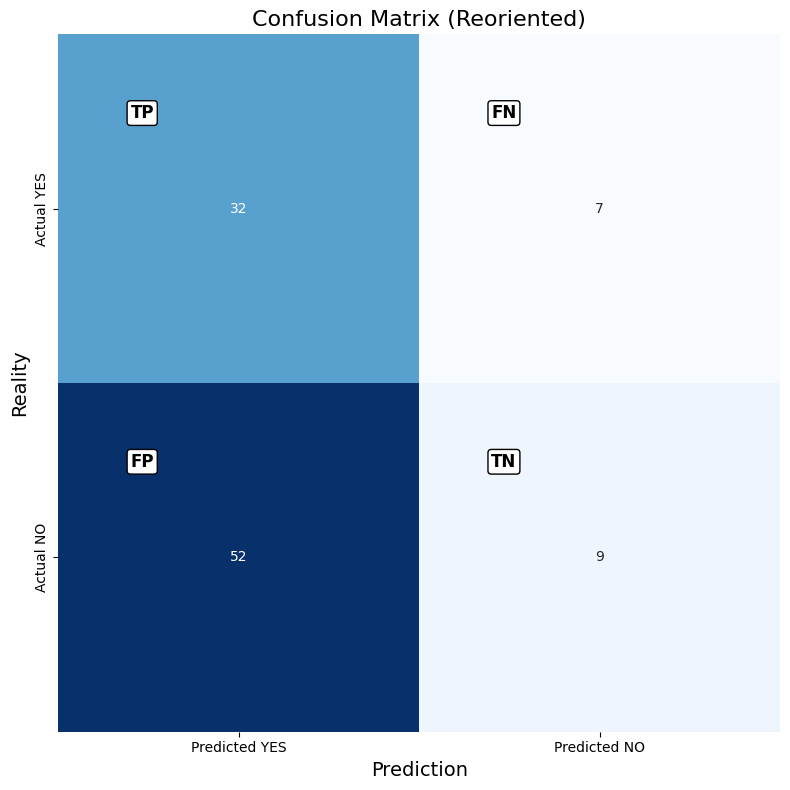

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Step 1: Get True Labels and Predicted Labels
# Flatten the true labels and predictions for the entire test dataset
y_true = tf.concat([y for _, y in test_dataset], axis=0).numpy()  # True labels from the test dataset
y_pred = tf.concat([model(x) for x, _ in test_dataset], axis=0).numpy()  # Predicted probabilities

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred_binary = (y_pred > 0.5).astype(int).flatten()

# Step 2: Compute the Confusion Matrix
cm = confusion_matrix(y_true, y_pred_binary)

# Step 3: Reorient the Confusion Matrix
# Reorient so that TP is top-left, FN is top-right, FP is bottom-left, TN is bottom-right
reoriented_cm = [[cm[1][1], cm[1][0]],  # TP, FN
                 [cm[0][1], cm[0][0]]]  # FP, TN

# Step 4: Plot the Reoriented Confusion Matrix
def plot_reoriented_confusion_matrix(cm):
    plt.figure(figsize=(8, 8))

    # Create the heatmap with the actual confusion matrix values
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted YES", "Predicted NO"], yticklabels=["Actual YES", "Actual NO"], cbar=False)
    plt.xlabel("Prediction", fontsize=14)
    plt.ylabel("Reality", fontsize=14)
    plt.title("Confusion Matrix (Reoriented)", fontsize=16)

    # Overlay TP, FN, FP, TN labels next to the numbers
    labels = [
        ("TP", 0, 0),  # Top-left
        ("FN", 0, 1),  # Top-right
        ("FP", 1, 0),  # Bottom-left
        ("TN", 1, 1)   # Bottom-right
    ]
    for text, row, col in labels:
        ax.text(
            col + 0.2, row + 0.2, text,  # Offset slightly so they don't overlap the numbers
            fontsize=12, fontweight="bold", color="black",
            ha="left", va="top", bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.2")
        )

    plt.tight_layout()
    plt.show()

# Plot the reoriented confusion matrix
plot_reoriented_confusion_matrix(reoriented_cm)

#**Step 5: Model Deployment**

### *Using the Model to Make Predictions*

After training and evaluation, we deploy the model to predict outcomes for new data. You’ll see how to:
1. Use the model to predict probabilities (e.g., attrition likelihood).
2. Interpret the model’s predictions in a business context.



## Making Predictions from New Data (Executed Manually)

In [16]:
# Example new data (create a single sample with the same feature order as the dataset)
# Need to ensure the new employee data has the same number of features and order as df_encoded after dropping columns
# Let's create a sample new employee data based on the columns of df_encoded (excluding 'LeftCompany', 'EmployeeID', and 'JobRole')
new_employee_data_dict = {col: [0] for col in df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']).columns}

# Update the dictionary with values for the new employee
# Example values. Make sure to include values for all features used in the model.
new_employee_data_dict['Age'] = [50]
new_employee_data_dict['Salary'] = [100000] # Example salary
new_employee_data_dict['Workload'] = [75]
new_employee_data_dict['YearsAtCompany'] = [15]
new_employee_data_dict['JobSatisfaction'] = [4]
# Only set Promotions if it exists in the dataframe
if 'Promotions' in new_employee_data_dict:
    new_employee_data_dict['Promotions'] = [1]
new_employee_data_dict['WorkLifeBalance'] = [3]
new_employee_data_dict['Overtime'] = [0]
new_employee_data_dict['RemoteWork'] = [0]
new_employee_data_dict['ManagerRating'] = [4]

# For Department='Sales', set Department_Sales to 1 if it exists (assuming one-hot encoded columns)
if 'Department_Sales' in new_employee_data_dict:
    new_employee_data_dict['Department_Sales'] = [1]
# For JobRole='Sales Executive', this column is now dropped as JobRole is excluded


new_employee_df = pd.DataFrame(new_employee_data_dict)

# Identify numerical columns for normalization (excluding one-hot encoded and binary columns)
# Start with all columns in df_encoded except target, ID, and one-hot encoded
all_features = df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']) # Also drop JobRole here
one_hot_encoded_columns = [col for col in all_features.columns if '_' in col] # Simple heuristic for one-hot encoded columns

# Numerical columns are those not in one-hot encoded list and are of numerical dtype
numerical_columns = [col for col in all_features.columns if col not in one_hot_encoded_columns and all_features[col].dtype != 'object']

# Separate numerical and other features for prediction
new_employee_numerical = new_employee_df[numerical_columns]
new_employee_other_features = new_employee_df.drop(columns=numerical_columns)


# Step 1: Re-create and adapt the normalizer using the training data
# Need to get the training data X_train and y_train from the dataset splitting step
# We can reuse X from the dataset splitting cell (DOZoDGRIlNX6) which is the full feature set before splitting
X_train_full = X[:train_size] # Use the full X data up to the training size defined in DOZoDGRIlNX6

# Print shape of X_train_full and columns being used for debugging
print("Shape of X_train_full:", X_train_full.shape)
print("Columns of df_encoded after dropping:", df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']).columns.tolist())


# Create a DataFrame from the full training data to easily select columns
X_train_full_df = pd.DataFrame(X_train_full, columns=df_encoded.drop(columns=['LeftCompany', 'EmployeeID', 'JobRole']).columns)

# Select only the numerical columns from the full training data to adapt the normalizer
X_train_numerical = X_train_full_df[numerical_columns].to_numpy()

# Create a new Normalization layer
normalizer = tf.keras.layers.Normalization(axis=-1)

# Adapt the normalizer to the numerical features of the training data
normalizer.adapt(X_train_numerical)


# Step 2: Normalize the numerical data of the new employee
normalized_new_employee_numerical = normalizer(new_employee_numerical.to_numpy())

# Step 3: Ensure the other features are in float32 for compatibility and the correct order
# Get the order of columns in X_train_full_df excluding numerical columns
other_feature_columns_order = X_train_full_df.drop(columns=numerical_columns).columns

# Select and reorder columns in new_employee_other_features to match the training data
new_employee_other_features_ordered = new_employee_other_features[other_feature_columns_order]

new_employee_other_features_float = tf.constant(new_employee_other_features_ordered.to_numpy(), dtype=tf.float32)


# Step 4: Combine normalized numerical and other features
final_new_employee = tf.concat([normalized_new_employee_numerical, new_employee_other_features_float], axis=1)


# Step 5: Predict the probability of attrition
prediction = model.predict(final_new_employee)
print(f"\nProbability of Attrition: {prediction[0][0]:.2%}")

# Step 6: Convert probability to binary prediction
threshold = 0.5
binary_prediction = int(prediction[0][0] > threshold)
print(f"Prediction: {'Will Leave' if binary_prediction == 1 else 'Will Stay'}")

Shape of X_train_full: (400, 20)
Columns of df_encoded after dropping: ['Age', 'Salary', 'YearsAtCompany', 'YearsSinceLastPromotion', 'JobSatisfaction', 'WorkLifeBalance', 'Overtime', 'RemoteWork', 'ManagerRating', 'StagnationRatio', 'Overtime_WorkLife', 'LowSatisfaction_Overtime', 'Salary_Department', 'Department_HR', 'Department_IT', 'Department_R&D', 'Department_Sales', 'JobRoleGroup_HR', 'JobRoleGroup_Sales', 'JobRoleGroup_Technical']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Probability of Attrition: 50.52%
Prediction: Will Leave


## **Saving the trained model to a file**

In [ ]:
# Save the trained model
# Save the model in TensorFlow's SavedModel format
model.save('employee_attrition_model.keras')
# HDF5 is a single-file format that saves the model’s architecture and weights.
model.save('employee_attrition_model.h5')
print("Model saved successfully!")

## **Deployment to Platforms - Hugging Face**

We can use the save model and host it on a Hugging Face "Space" where it will run as an application and "serve" responses. This is refer to an "inference" workload when the model is deployed into production to generate predictions based on a trained model.

See the [Employee Attrition space on Hugging Face](https://huggingface.co/spaces/jamesgray007/employee-attrition)

---

# **Step 6: Monitoring**


---

# **Step 7. Recap and Next Steps**
### *Reviewing the Lifecycle*

Let’s summarize what we covered:
1. Understanding the business problem and defining the ML problem.
2. Preparing the data through preprocessing.
3. Building, training, and evaluating a machine learning model.
4. Deploying the model for predictions.
5. Discussing monitoring strategies for long-term success.

### **Next Steps:**
-

---